# Exploratory Data Analysis (EDA)

## 0. Setup and configuration

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ----------------------------- CONFIGURATION -----------------------------
DATA_PATH = "../data/raw/dataset.csv"
SAVE_PATH = "../data/raw/dataset_eda.csv"          
TARGET = "popularity"                          
MISSING_DROP_THRESHOLD = 0.50                  # drop columns with more than 50% missing values
CATEGORICAL_MAX_UNIQUE = 15                    # numeric columns with <= this many unique values are treated as categorical
IQR_FACTOR = 1.5                               # Tukey fences multiplier for outliers
Z_THRESHOLD = 3.0                              # |z-score| threshold for outliers
RANDOM_STATE = 42

# --------------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)

---
## 1. Initial inspection and structure
Goals: understand *what* we have (types), *how much* (dimensions) and verify that the data loaded correctly (head/tail).

In [46]:
# --- 1.1 Dimensions
n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,} | Columns: {n_cols}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Rows: 114,000 | Columns: 21
Memory usage: 54.31 MB


In [47]:
# --- 1.2 First and last records (sanity check that loading worked: headers, delimiters, trailing junk rows)
display(df.head())
display(df.tail())

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.042,0.640,0.928,0.086,0.034,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.040,0.994,0.976,0.105,0.035,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.042,0.867,0.000,0.084,0.743,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.030,0.381,0.000,0.270,0.413,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.072,0.681,0.000,0.089,0.708,79.198,4,world-music


In [48]:
# --- 1.3 Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [49]:
# --- 1.4 Semantic classification of variables
# A numeric dtype does not always mean a numeric *variable* (e.g. a 0/1 flag or a rating 1-5 is categorical in nature).
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Low-cardinality numeric columns are treated as categorical (excluding the target)
low_card_numeric = [c for c in numeric_cols if df[c].nunique() <= CATEGORICAL_MAX_UNIQUE and c != TARGET]
numeric_cols = [c for c in numeric_cols if c not in low_card_numeric]
categorical_cols = categorical_cols + low_card_numeric

# Split numeric into integer-valued (discrete) and continuous
def is_integer_valued(s):
    s = s.dropna()
    return len(s) > 0 and np.allclose(s, s.round())

integer_cols = [c for c in numeric_cols if is_integer_valued(df[c])]
continuous_cols = [c for c in numeric_cols if c not in integer_cols]

summary_types = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "kind": ["numerical - integer" if c in integer_cols else
             "numerical - continuous" if c in continuous_cols else
             "categorical" for c in df.columns],
    "n_unique": df.nunique().values,
}).set_index("variable")
display(summary_types)
print(f"Numerical: {numeric_cols}\nCategorical: {categorical_cols}")

,dtype,kind,n_unique
variable,,,
Unnamed: 0,int64,numerical - integer,114000
track_id,str,categorical,89741
artists,str,categorical,31437
album_name,str,categorical,46589
track_name,str,categorical,73608
popularity,int64,numerical - integer,101
duration_ms,int64,numerical - integer,50697
explicit,bool,categorical,2
danceability,float64,numerical - continuous,1174


Numerical: ['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Categorical: ['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre', 'key', 'mode', 'time_signature']


---
## 2. Preliminary cleaning
### 2.1 Missing values

,n_missing,pct_missing
artists,1,0.001
track_name,1,0.001
album_name,1,0.001


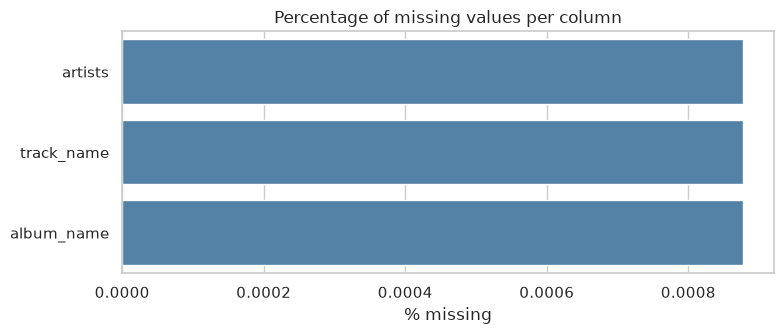

In [50]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean() * 100,
}).sort_values("pct_missing", ascending=False)
display(missing[missing.n_missing > 0] if (missing.n_missing > 0).any() else "No missing values found")

if (missing.n_missing > 0).any():
    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.barplot(data=missing[missing.n_missing > 0].reset_index(), x="pct_missing", y="index", color="steelblue", ax=ax)
    ax.set(title="Percentage of missing values per column", xlabel="% missing", ylabel="")
    plt.tight_layout(); plt.show()

In [51]:
# --- 2.2 Duplicates (do this BEFORE imputing so duplicates are detected on the raw values)
n_dup = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dup} ({n_dup / len(df):.2%})")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Fully duplicated rows: 0 (0.00%)
Shape after removing duplicates: (114000, 21)


In [52]:
# --- 2.3 Apply the missing-value strategy
df_clean = df.copy()

# (a) Drop columns that are mostly empty
cols_to_drop = missing.index[missing.pct_missing / 100 > MISSING_DROP_THRESHOLD].tolist()
df_clean = df_clean.drop(columns=cols_to_drop)
print("Dropped columns (too many NaN):", cols_to_drop or "none")

# (b) Never impute the target: rows without target are not useful for supervised analysis
if TARGET and TARGET in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean.dropna(subset=[TARGET])
    print(f"Rows dropped for missing target: {before - len(df_clean)}")

# (c) Impute remaining columns
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]
categorical_cols = [c for c in categorical_cols if c in df_clean.columns]

for col in df_clean.columns:
    if df_clean[col].isna().any():
        if col in numeric_cols:
            # Median for skewed variables, mean otherwise (|skew| > 1 is a common rule of thumb)
            fill = df_clean[col].median() if abs(df_clean[col].skew()) > 1 else df_clean[col].mean()
            if col in integer_cols:
                fill = round(fill)
            strategy = "median/mean"
        else:
            fill = df_clean[col].mode().iloc[0]
            strategy = "mode"
        df_clean[col] = df_clean[col].fillna(fill)
        print(f"  {col:<20} imputed with {strategy}: {fill}")

print("\nRemaining missing values:", int(df_clean.isna().sum().sum()))
df = df_clean

Dropped columns (too many NaN): none
Rows dropped for missing target: 0
  artists              imputed with mode: The Beatles
  album_name           imputed with mode: Alternative Christmas 2022
  track_name           imputed with mode: Run Rudolph Run

Remaining missing values: 0


---
## 3. Univariate analysis
### 3.1 Numerical variables
Key statistics plus **skewness** and **kurtosis** (shape of the distribution), followed by a histogram (with KDE) and boxplot per variable.

In [53]:
stats = df[numeric_cols].agg(["count", "mean", "median", "std", "min", "max", "skew", "kurt"]).T
display(stats)

,count,mean,median,std,min,max,skew,kurt
Unnamed: 0,"114,000.000","56,999.500","56,999.500","32,909.110",0.000,"113,999.000",-0.000,-1.200
popularity,"114,000.000",33.239,35.000,22.305,0.000,100.000,0.046,-0.928
duration_ms,"114,000.000","228,029.153","212,906.000","107,297.713",0.000,"5,237,295.000",11.195,354.952
danceability,"114,000.000",0.567,0.580,0.174,0.000,0.985,-0.399,-0.185
energy,"114,000.000",0.641,0.685,0.252,0.000,1.000,-0.597,-0.526
loudness,"114,000.000",-8.259,-7.004,5.029,-49.531,4.532,-2.007,5.896
speechiness,"114,000.000",0.085,0.049,0.106,0.000,0.965,4.648,28.824
acousticness,"114,000.000",0.315,0.169,0.333,0.000,0.996,0.727,-0.950
instrumentalness,"114,000.000",0.156,0.000,0.310,0.000,1.000,1.734,1.271
liveness,"114,000.000",0.214,0.132,0.190,0.000,1.000,2.106,4.378


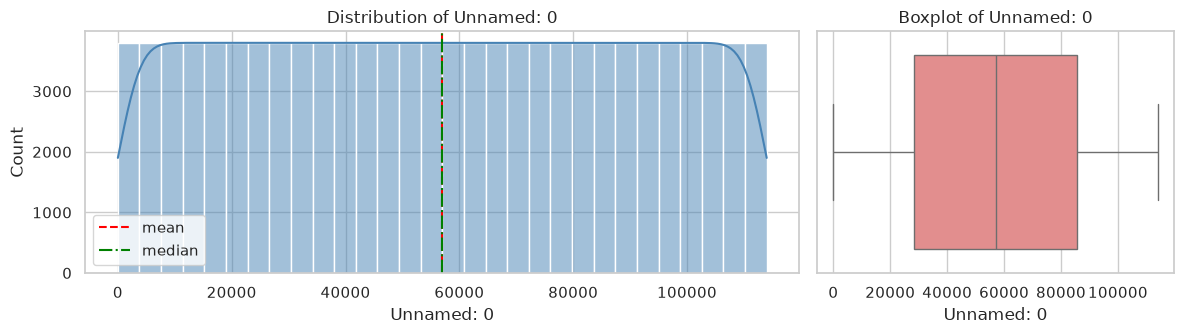

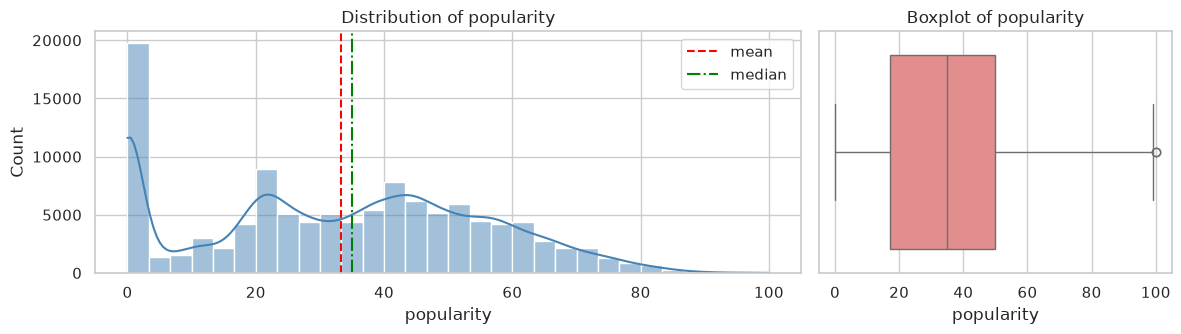

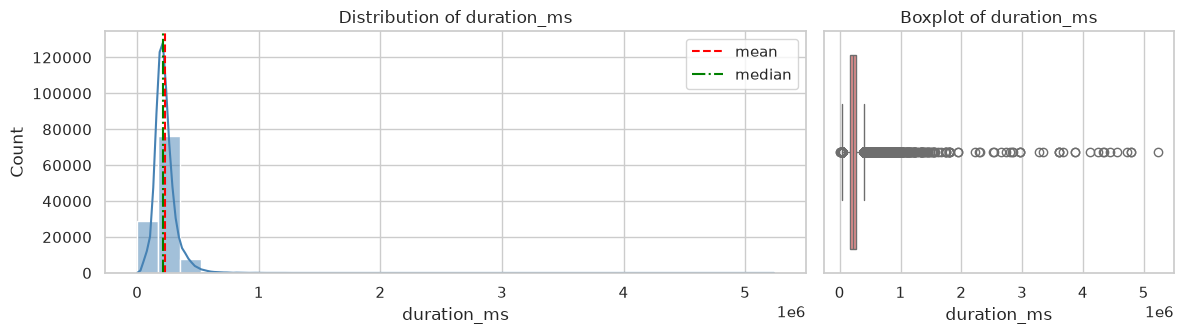

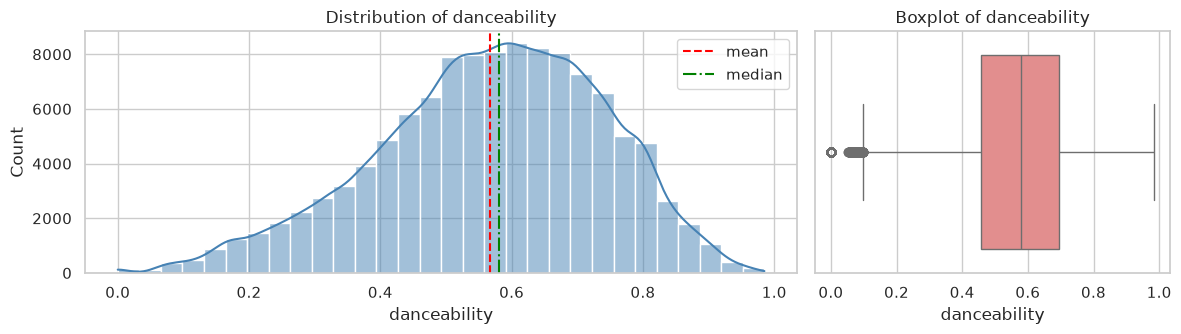

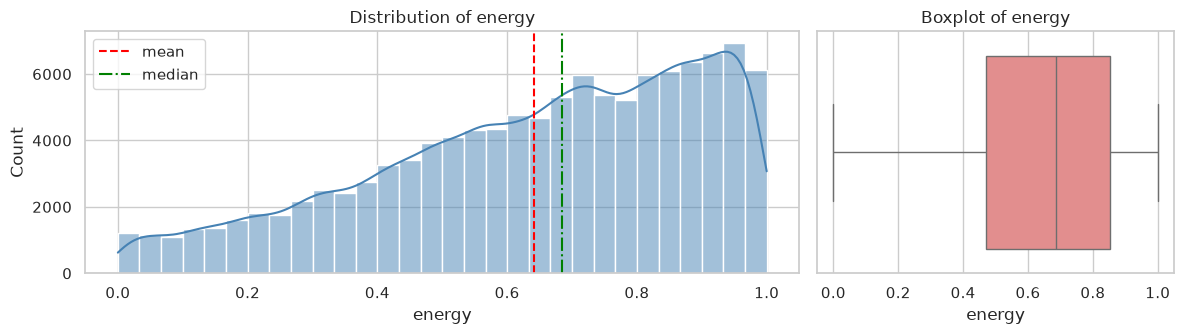

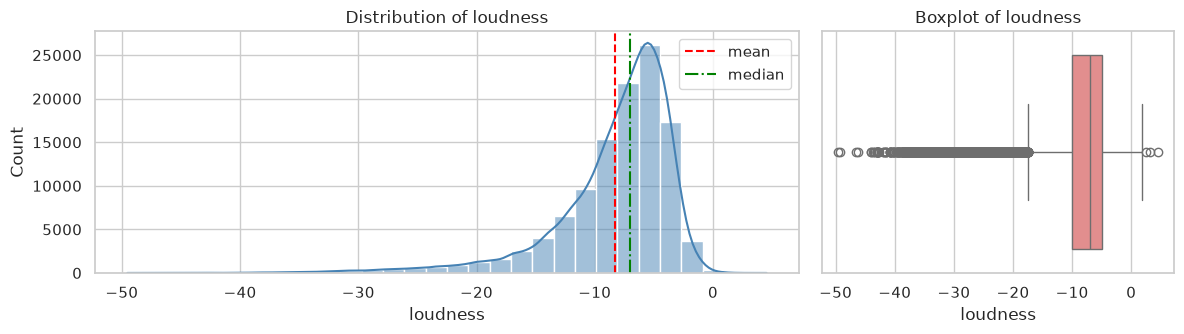

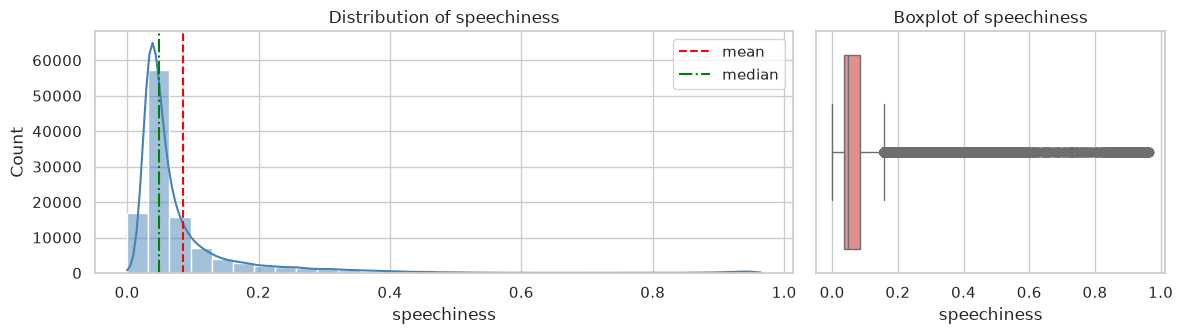

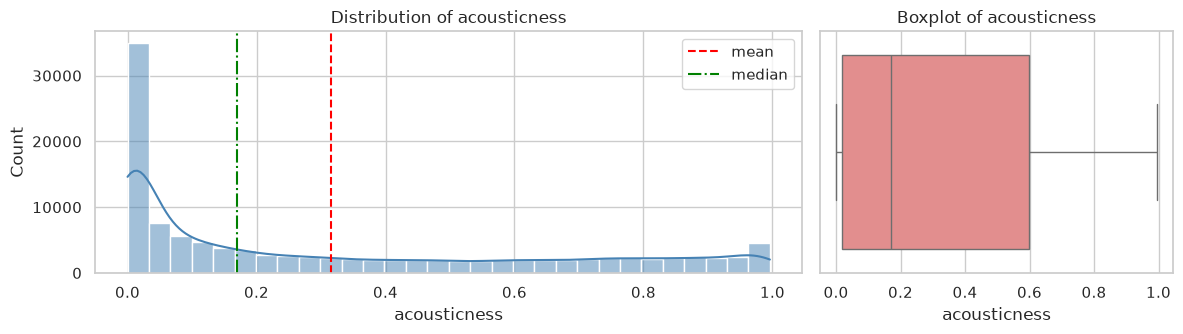

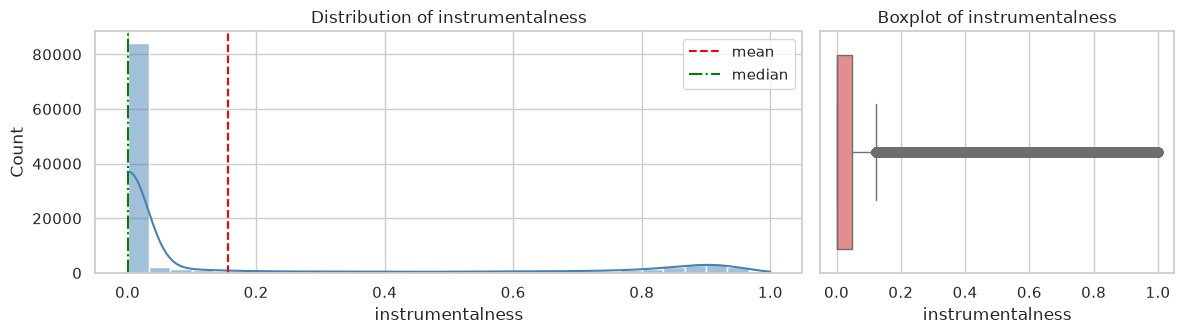

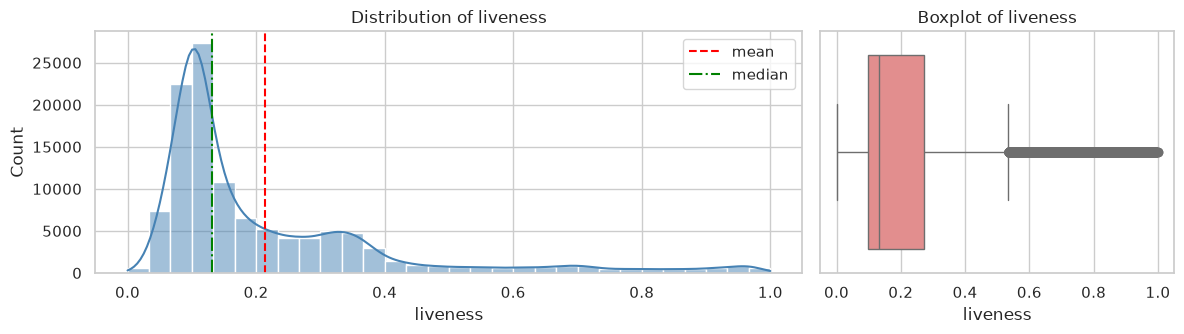

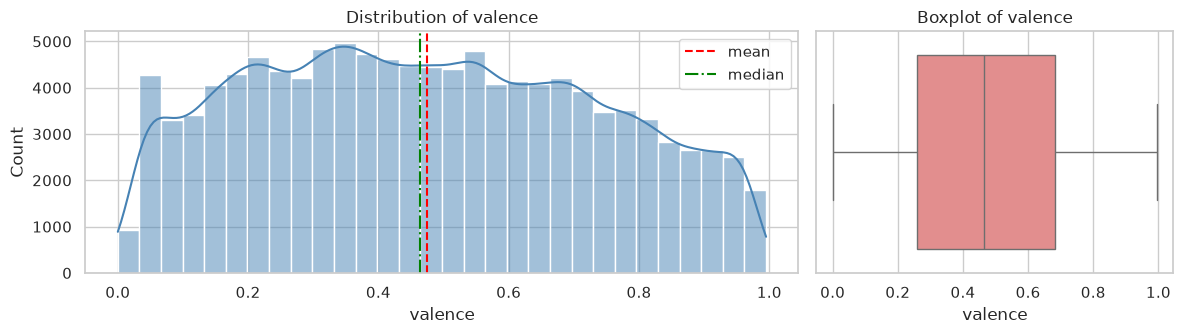

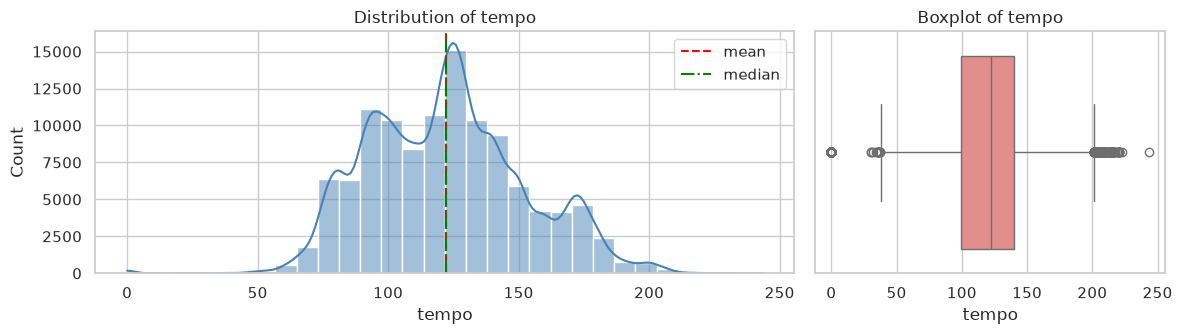

In [54]:
def plot_numeric(df, cols):
    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [2, 1]})
        sns.histplot(df[col], kde=True, bins=30, color="steelblue", ax=axes[0])
        axes[0].axvline(df[col].mean(), color="red", ls="--", label="mean")
        axes[0].axvline(df[col].median(), color="green", ls="-.", label="median")
        axes[0].legend(); axes[0].set_title(f"Distribution of {col}")
        sns.boxplot(x=df[col], color="lightcoral", ax=axes[1])
        axes[1].set_title(f"Boxplot of {col}")
        plt.tight_layout(); plt.show()

plot_numeric(df, numeric_cols)

In [55]:
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    freq = pd.DataFrame({"count": counts, "percentage": (counts / len(df) * 100).round(2)})
    print(f"\n=== {col} ({df[col].nunique()} categories) ===")
    display(freq.head(15))


=== track_id (89741 categories) ===


,count,percentage
track_id,,
6S3JlDAGk3uu3NtZbPnuhS,9,0.010
2kkvB3RNRzwjFdGhaUA0tz,8,0.010
2Ey6v4Sekh3Z0RUSISRosD,8,0.010
2vU6bm5hVF2idVknGzqyPL,7,0.010
4GPQDyw9hC1DiZVh0ouDVL,7,0.010
5ftfVzSLIi5ZxYdNbRtf41,7,0.010
6bzWr3EpSEolVwlbLk58il,7,0.010
2aaClnypAakdAmLw74JXxB,7,0.010
4WJTKbNJQ41zXnb84jSWaj,7,0.010



=== artists (31437 categories) ===


,count,percentage
artists,,
The Beatles,280,0.250
George Jones,271,0.240
Stevie Wonder,236,0.210
Linkin Park,224,0.200
Ella Fitzgerald,222,0.190
Prateek Kuhad,217,0.190
Feid,202,0.180
Chuck Berry,190,0.170
Håkan Hellström,183,0.160



=== album_name (46589 categories) ===


...

,count,percentage
key,,
7,13245,11.620
0,13061,11.460
2,11644,10.210
9,11313,9.920
1,10772,9.450
5,9368,8.220
11,9282,8.140
4,9008,7.900
6,7921,6.950



=== mode (2 categories) ===


,count,percentage
mode,,
1,72681,63.760
0,41319,36.240



=== time_signature (5 categories) ===


,count,percentage
time_signature,,
4,101843,89.340
3,9195,8.070
5,1826,1.600
1,973,0.850
0,163,0.140


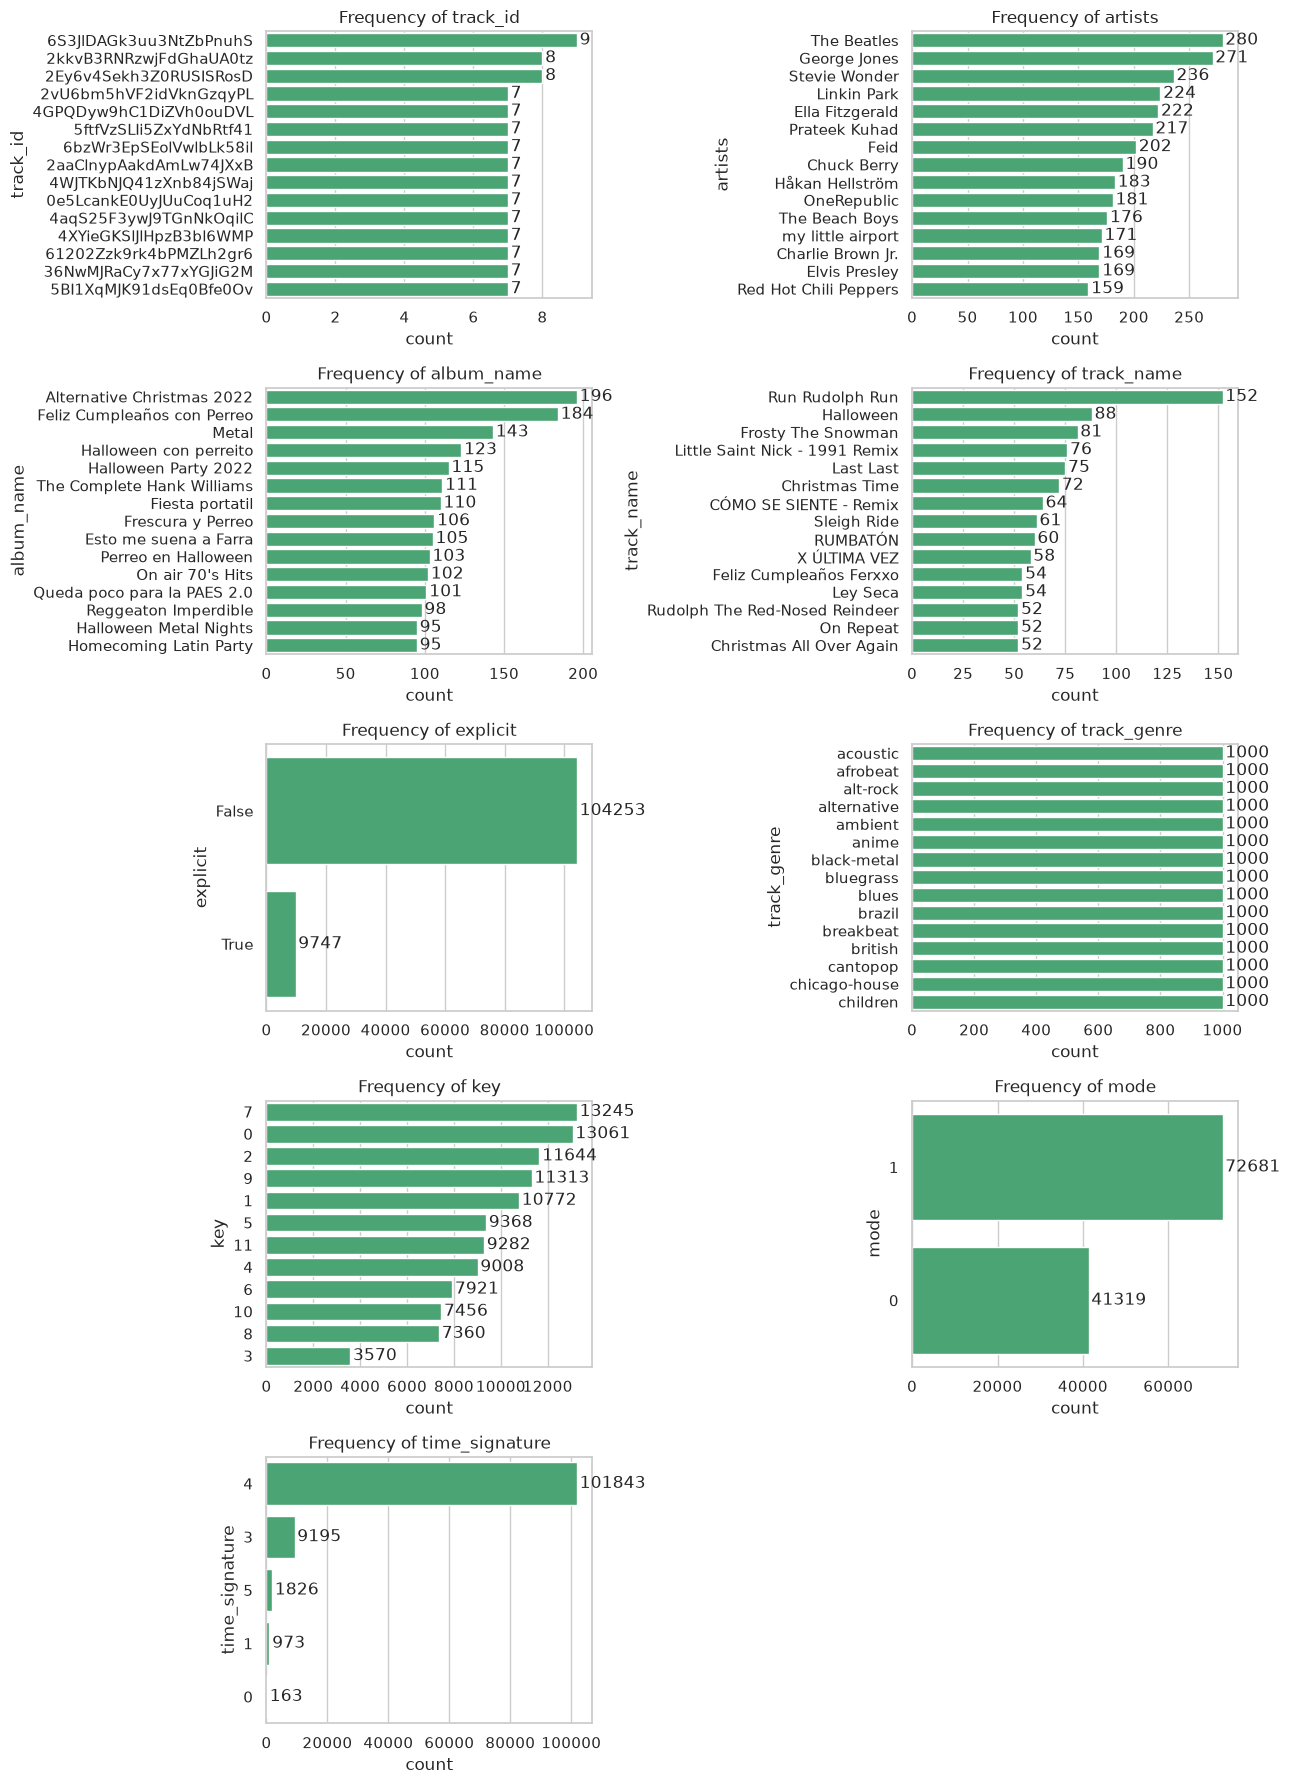

In [56]:
def plot_categorical(df, cols, top_n=15):
    n = len(cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, cols):
        order = df[col].value_counts().head(top_n).index
        sns.countplot(data=df, y=col, order=order, color="mediumseagreen", ax=ax)
        ax.set_title(f"Frequency of {col}")
        for container in ax.containers:
            ax.bar_label(container, padding=2)
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

if categorical_cols:
    plot_categorical(df, categorical_cols)

---
## 4. Bivariate and multivariate analysis
### 4.1 Correlation matrix
Pearson measures *linear* association; Spearman is rank-based and captures monotonic (non-linear) relationships and is more robust to outliers. Values close to ±1 between two predictors indicate multicollinearity.

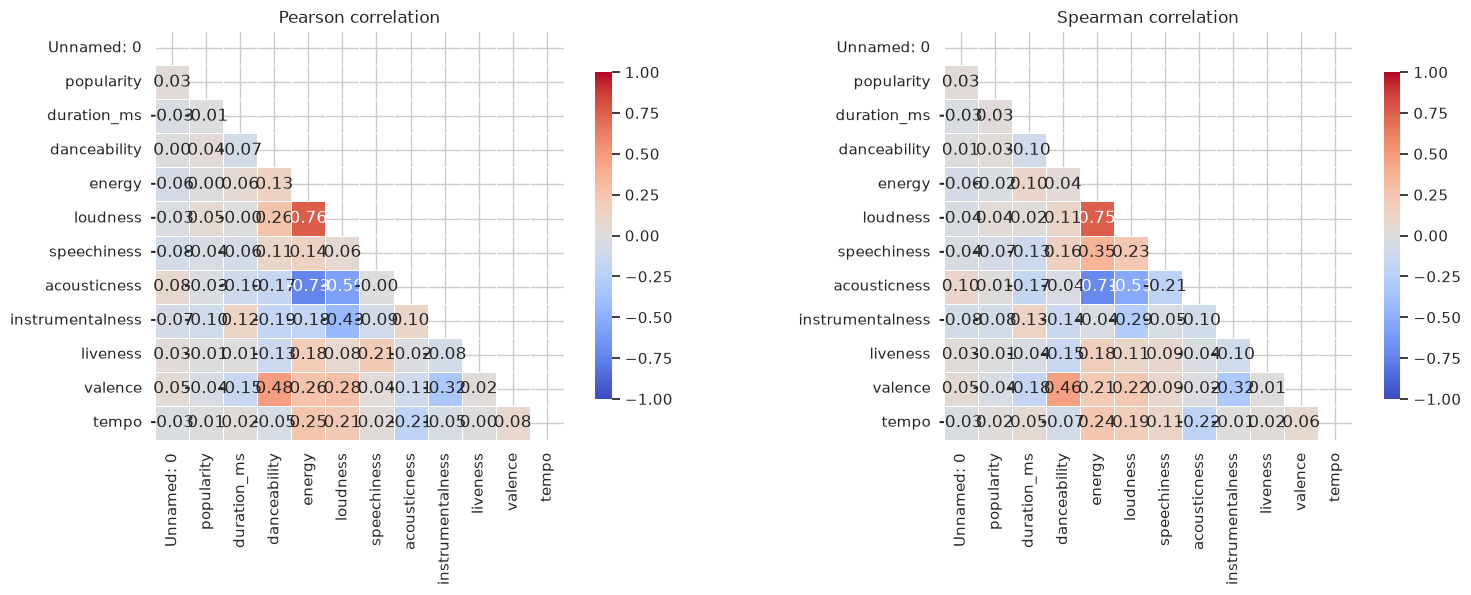

In [57]:
corr_cols = numeric_cols + ([TARGET] if TARGET and TARGET not in numeric_cols and TARGET in df.columns else [])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = df[corr_cols].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title(f"{method.capitalize()} correlation")
plt.tight_layout(); plt.show()

In [58]:
# Strongest correlated pairs
corr = df[corr_cols].corr()
pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
             .stack().rename("correlation").reset_index()
             .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
pairs["abs_corr"] = pairs.correlation.abs()
display(pairs.sort_values("abs_corr", ascending=False).drop(columns="abs_corr").head(10))

,var_1,var_2,correlation
64,loudness,energy,0.762
88,acousticness,energy,-0.734
89,acousticness,loudness,-0.590
123,valence,danceability,0.477
101,instrumentalness,loudness,-0.433
128,valence,instrumentalness,-0.324
125,valence,loudness,0.280
63,loudness,danceability,0.259
124,valence,energy,0.259
136,tempo,energy,0.248


In [60]:
from scipy import stats

if TARGET and TARGET in df.columns and pd.api.types.is_numeric_dtype(df[TARGET]):
    y = df[TARGET]
    results_num = []

    for col in [c for c in numeric_cols if c != TARGET]:
        r_pearson, p_val = stats.pearsonr(df[col], y)
        r_spearman = df[col].corr(y, method="spearman")
        results_num.append({
            "variable": col,
            "pearson": r_pearson,
            "spearman": r_spearman,
            "abs_pearson": abs(r_pearson),
            "p_value": p_val,
        })

    num_assoc = (pd.DataFrame(results_num)
                   .sort_values("abs_pearson", ascending=False)
                   .drop(columns="abs_pearson")
                   .reset_index(drop=True))

    display(num_assoc.head(10))

,variable,pearson,spearman,p_value
0,instrumentalness,-0.095,-0.078,0.000
1,loudness,0.050,0.035,0.000
2,speechiness,-0.045,-0.068,0.000
3,valence,-0.041,-0.042,0.000
4,danceability,0.035,0.027,0.000
5,Unnamed: 0,0.032,0.033,0.000
6,acousticness,-0.025,0.008,0.000
7,tempo,0.013,0.017,0.000
8,duration_ms,-0.007,0.028,0.017
9,liveness,-0.005,-0.008,0.069


In [61]:
if TARGET and TARGET in df.columns and pd.api.types.is_numeric_dtype(df[TARGET]):
    y = df[TARGET]
    ss_total = ((y - y.mean()) ** 2).sum()
    results_cat = []

    for col in [c for c in categorical_cols if c != TARGET]:
        groups = df.groupby(col)[TARGET]

        # Correlation ratio (eta): share of target variance explained by the categories
        ss_between = (groups.count() * (groups.mean() - y.mean()) ** 2).sum()
        eta = np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

        # ANOVA p-value (needs at least 2 groups)
        try:
            p_val = stats.f_oneway(*[g.values for _, g in groups]).pvalue
        except ValueError:
            p_val = np.nan

        results_cat.append({
            "variable": col,
            "n_categories": df[col].nunique(),
            "eta": eta,
            "p_value": p_val,
        })

    cat_assoc = (pd.DataFrame(results_cat)
                   .sort_values("eta", ascending=False)
                   .reset_index(drop=True))

    display(cat_assoc.head(10))

,variable,n_categories,eta,p_value
0,track_id,89741,1.000,0.000
1,album_name,46589,0.976,0.000
2,track_name,73608,0.915,0.000
3,artists,31437,0.856,0.000
4,track_genre,114,0.504,0.000
5,time_signature,5,0.058,0.000
6,explicit,2,0.044,0.000
7,key,12,0.032,0.000
8,mode,2,0.014,0.000


---
## 5. Outlier detection
We use two complementary methods:

- **IQR / Tukey fences:** a value is an outlier if it is below `Q1 - 1.5·IQR` or above `Q3 + 1.5·IQR`. Distribution-free, robust.
- **Z-score:** a value is an outlier if `|z| > 3`. Assumes roughly normal data and is itself sensitive to extreme values.

Rows flagged by *both* methods deserve the closest inspection.

In [62]:
def detect_outliers(df, cols, iqr_factor=IQR_FACTOR, z_thr=Z_THRESHOLD):
    rows, flags = [], pd.DataFrame(index=df.index)
    for col in cols:
        s = df[col]
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - iqr_factor * iqr, q3 + iqr_factor * iqr
        iqr_mask = (s < lo) | (s > hi)
        z_mask = ((s - s.mean()) / s.std()).abs() > z_thr
        flags[f"{col}_iqr"], flags[f"{col}_z"] = iqr_mask, z_mask
        rows.append({"variable": col, "lower_fence": lo, "upper_fence": hi,
                     "n_outliers_IQR": int(iqr_mask.sum()), "pct_IQR": iqr_mask.mean() * 100,
                     "n_outliers_Z": int(z_mask.sum()), "n_both": int((iqr_mask & z_mask).sum())})
    return pd.DataFrame(rows).set_index("variable"), flags

outlier_summary, outlier_flags = detect_outliers(df, numeric_cols + ([TARGET] if TARGET in df.columns and TARGET not in numeric_cols else []))
display(outlier_summary)

,lower_fence,upper_fence,n_outliers_IQR,pct_IQR,n_outliers_Z,n_both
variable,,,,,,
Unnamed: 0,"-56,999.500","170,998.500",0,0.000,0,0
popularity,-32.500,99.500,2,0.002,0,0
duration_ms,"42,906.000","392,666.000",5617,4.927,946,946
danceability,0.098,1.053,620,0.544,157,157
energy,-0.101,1.427,0,0.000,0,0
loudness,-17.528,2.512,6173,5.415,2475,2475
speechiness,-0.037,0.157,13211,11.589,2079,2079
acousticness,-0.855,1.470,0,0.000,0,0
instrumentalness,-0.074,0.123,25246,22.146,0,0


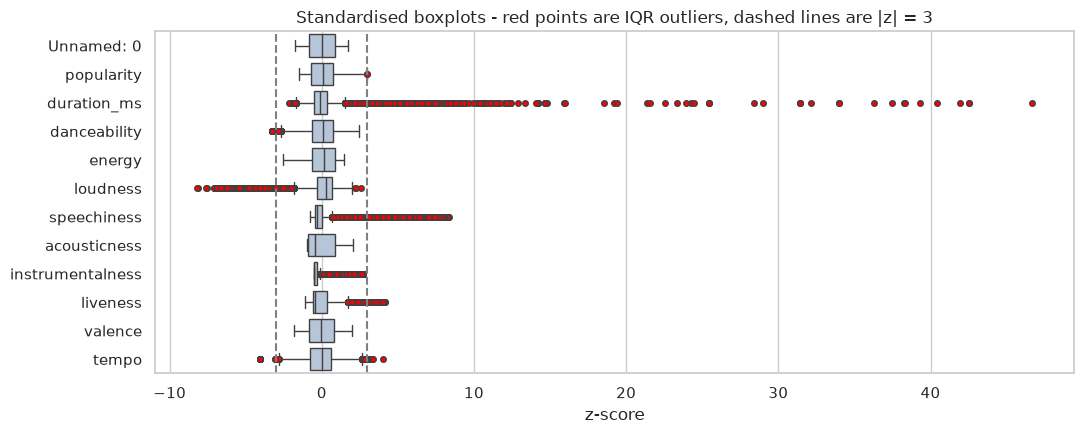

In [63]:
# Visualize outliers: boxplots (standardised so all variables share one axis)
cols = outlier_summary.index.tolist()
z = (df[cols] - df[cols].mean()) / df[cols].std()
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=z, orient="h", color="lightsteelblue", flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 4}, ax=ax)
ax.axvline(-Z_THRESHOLD, color="gray", ls="--"); ax.axvline(Z_THRESHOLD, color="gray", ls="--")
ax.set(title="Standardised boxplots - red points are IQR outliers, dashed lines are |z| = 3", xlabel="z-score")
plt.tight_layout(); plt.show()

In [64]:
MAX_ROWS_PER_FEATURE = 10   # max records shown per feature (set to None to show all)

extreme_by_feature = {}

for col in cols:
    # Rows flagged by BOTH methods for this specific feature
    mask = outlier_flags[f"{col}_iqr"] & outlier_flags[f"{col}_z"]
    if not mask.any():
        continue

    z_score = ((df[col] - df[col].mean()) / df[col].std()).rename(f"{col}_zscore")
    extreme = (df.loc[mask]
                 .join(z_score)
                 .assign(abs_z=lambda d: d[f"{col}_zscore"].abs())
                 .sort_values("abs_z", ascending=False)
                 .drop(columns="abs_z"))

    extreme_by_feature[col] = extreme   # keep the full result for later use

    print(f"\n{'=' * 70}\n{col}: {mask.sum()} extreme records "
          f"(fences: [{outlier_summary.loc[col, 'lower_fence']:,.2f}, "
          f"{outlier_summary.loc[col, 'upper_fence']:,.2f}])\n{'=' * 70}")
    display(extreme if MAX_ROWS_PER_FEATURE is None else extreme.head(MAX_ROWS_PER_FEATURE))

if not extreme_by_feature:
    print("No extreme records flagged by both methods in any feature.")


duration_ms: 946 extreme records (fences: [42,906.00, 392,666.00])


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_ms_zscore
73617,73617,3Cnz3Bu9Wcw8p3kiBTXTxp,Tale Of Us,Unity (Voyage Mix),Unity (Voyage Mix) Pt. 1,35,5237295,False,0.695,0.736,5,-11.371,0,0.037,0.004,0.860,0.091,0.051,124.001,4,minimal-techno,46.686
10984,10984,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Compiled And Mixed By Tim...,Crossing Wires 002 - Continuous DJ Mix,11,4789026,False,0.697,0.632,1,-12.469,1,0.045,0.008,0.871,0.100,0.151,121.055,4,breakbeat,42.508
10935,10935,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Compiled And Mixed By Tim...,Crossing Wires 002 - Continuous DJ Mix,11,4789026,False,0.697,0.632,1,-12.469,1,0.045,0.008,0.871,0.100,0.151,121.055,4,breakbeat,42.508
24348,24348,6wypxnAvmv5zYewUX3VFDd,Seth Troxler,Seth Troxler - The Lab 03,The Lab 03 - Continuous DJ Mix Part 1,8,4730302,False,0.684,0.656,5,-11.163,0,0.063,0.019,0.848,0.103,0.301,123.180,4,detroit-techno,41.961
73840,73840,6JbQr97EMFD2D3Ek6gxgt1,Loco Dice,Amnesia Ibiza - Underground 10,Amnesia Ibiza Underground 10 DJ Mix,17,4563897,False,0.783,0.728,10,-10.176,0,0.061,0.002,0.840,0.158,0.189,125.044,4,minimal-techno,40.410
13344,13344,3gFme8BdfTtFHxKmuTnSbj,Mark Farina,House of OM (DJ Mix),House of Om - Mark Farina - Continuous Mix,11,4447520,False,0.861,0.805,11,-6.461,0,0.071,0.005,0.577,0.135,0.545,129.306,4,chicago-house,39.325
13245,13245,13hQAhg1owjTpTcI9xQc6c,Mark Farina,Live In Tokyo,Live In Tokyo - Continuous Mix,11,4339826,False,0.806,0.582,1,-12.181,1,0.087,0.008,0.237,0.328,0.686,128.368,4,chicago-house,38.321
13195,13195,3se0UYprtkHthJEBuk1A5K,Mark Farina,Greenhouse Construction,Greenhouse Construction,12,4334721,False,0.846,0.744,10,-9.260,0,0.061,0.004,0.335,0.313,0.532,125.434,4,chicago-house,38.274
27926,27926,6eTDnsdPlRUyrTHqFj3l7W,Lenzman;Dan Stezo,NQ State of Mind,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",15,4246206,True,0.593,0.924,1,-3.979,1,0.090,0.004,0.022,0.534,0.242,173.938,4,drum-and-bass,37.449
101390,101390,2QfFLpSGF1T1pY6tq4kD7Z,Ocean Sounds,Ocean Waves Sounds to Relax and Sleep,Ocean Waves Sounds,39,4120258,False,0.080,0.995,1,-17.379,1,0.061,0.932,0.562,0.310,0.000,84.788,3,sleep,36.275



danceability: 157 extreme records (fences: [0.10, 1.05])


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,danceability_zscore
4131,4131,59gg6zQhSKGVnkT3hWAY3l,Max Richter;Lang Lang,Voyager - Essential Max Richter,The Departure,64,151506,False,0.000,0.036,0,-22.519,0,0.000,0.994,0.940,0.096,0.000,0.000,0,ambient,-3.266
4379,4379,4acmzQsAeMJa5sGFSog7fu,Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,Jane Eyre - Original Motion Picture Soundtrack,The End of Childhood (feat. Jack Liebeck),55,73266,False,0.000,0.044,0,-26.440,0,0.000,0.972,0.972,0.087,0.000,0.000,0,ambient,-3.266
4664,4664,1Kb2DqjHRvOcT5xeWtz3t5,Sylvain Chauveau,Des Plumes Dans La Tête,Ferme Les Yeux,53,68493,False,0.000,0.032,2,-23.636,0,0.000,0.994,0.973,0.092,0.000,0.000,0,ambient,-3.266
45670,45670,6B9Mgf9smWqxDjA35VD6MK,Little Symphony,Rialto Beach,Campomoro,22,148711,False,0.000,0.001,0,-30.204,1,0.000,0.952,0.991,0.242,0.000,0.000,0,guitar,-3.266
45720,45720,7i5OoyPXtSrqz9jobJfG1F,Little Symphony,Rialto Beach,Ritornello,23,102000,False,0.000,0.001,7,-29.445,1,0.000,0.969,0.956,0.123,0.000,0.000,0,guitar,-3.266
45729,45729,0pTAEdockvKVSq1hhFqk7O,Little Symphony,Rialto Beach,Amager,22,133624,False,0.000,0.004,0,-28.326,1,0.000,0.970,0.959,0.109,0.000,0.000,0,guitar,-3.266
45773,45773,1keWmyG6qyBbMagPBdgUKr,Little Symphony,Rialto Beach,Ionian,22,93125,False,0.000,0.027,7,-30.100,1,0.000,0.964,0.993,0.124,0.000,0.000,0,guitar,-3.266
59221,59221,5BcyxCXrXuw4vsAqAiObWM,Leila Bela,Angra Manyu,Yes! No! I Mean Yes! No I Don't!,0,38333,False,0.000,0.572,8,-16.286,1,0.000,0.872,0.000,0.119,0.000,0.000,0,iranian,-3.266
59310,59310,6hsyfegVY5yklJneM40mWi,Leila Bela,Angra Manyu,The Exorsism Begins...,0,8586,False,0.000,0.040,8,-29.714,0,0.000,0.928,0.956,0.115,0.000,0.000,0,iranian,-3.266
59473,59473,48Nt8u7kYSTwE6axtE9hJO,Leila Bela,Angra Manyu,Leaving Her Quantum Journey Behind...,0,50186,False,0.000,0.031,5,-28.194,0,0.000,0.723,0.000,0.129,0.000,0.000,0,iranian,-3.266



loudness: 2475 extreme records (fences: [-17.53, 2.51])


...

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,speechiness_zscore
18152,18152,5j7NfGi2DdRJU6Zj7fSiWL,Tenacious D,Post-Apocalypto,turd whistle,26,39426,True,0.630,0.249,4,-14.952,1,0.965,0.353,0.000,0.193,0.739,172.243,3,comedy,8.326
18504,18504,2LEkBYeP1mmlcoJmAl1LNF,Tom Papa,Human Mule,The Real World,22,68758,False,0.537,0.548,5,-15.100,0,0.963,0.736,0.000,0.745,0.730,179.403,3,comedy,8.307
18530,18530,2qOJ2ucNveZ8Di2GVWCBFr,Patton Oswalt,Talking for Clapping,Less and Less Radical,23,207619,True,0.650,0.461,7,-18.317,1,0.963,0.848,0.000,0.732,0.365,50.324,4,comedy,8.307
18432,18432,6HyWF4aQ7r62g8cRqCrXz2,Robert Schimmel,Life Since Then,Chemotherapy,22,132520,True,0.599,0.369,6,-20.816,1,0.962,0.921,0.000,0.696,0.494,83.026,5,comedy,8.298
18663,18663,3JLsjVkdmrjrbvP1Uiu4IV,Tom Papa,Human Mule,The Human Contract,21,339521,False,0.617,0.592,2,-13.854,1,0.962,0.721,0.000,0.752,0.465,90.721,4,comedy,8.298
18666,18666,09YownXjN4uwke2gAtMtE2,Tom Papa,Human Mule,Angry Young Men,21,136820,False,0.587,0.558,11,-14.645,0,0.962,0.795,0.000,0.807,0.559,88.127,4,comedy,8.298
18227,18227,15sAxWCkI9yocuqXEGyx1c,Patton Oswalt,Talking for Clapping,Parents and Pills,25,202358,True,0.552,0.431,10,-18.837,1,0.962,0.872,0.000,0.674,0.448,78.361,4,comedy,8.298
18137,18137,2pyPe084AvBeM4VxqdWet3,Dan Cummins,Get Outta Here; Devil!,Get Rid of That Joke!,25,191399,True,0.604,0.619,5,-13.426,1,0.962,0.682,0.000,0.860,0.562,88.668,3,comedy,8.298
18674,18674,3EUINDmmFZJ66Jgk8nfwIy,Tom Papa,Human Mule,Morning Tom,21,213995,False,0.526,0.667,6,-15.417,1,0.962,0.772,0.000,0.751,0.259,171.074,4,comedy,8.298
18067,18067,65BkbrG8XPEpPAHA4jgYhW,Robert Schimmel,Life Since Then,Non Hogkins Lymphoma,28,68520,True,0.689,0.332,2,-19.407,1,0.961,0.873,0.000,0.660,0.701,80.739,4,comedy,8.288



liveness: 3634 extreme records (fences: [-0.16, 0.54])


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,liveness_zscore
90597,90597,3rbAG0mVCVmhEPhFs96deC,Marco Antonio Muñiz;Jorge Muñiz;Mariano Perez,El Lujo de México (En Vivo),Solito Con las Estrellas / Yolanda (with Jorge...,32,339733,False,0.408,0.693,5,-6.400,1,0.076,0.624,0.000,1.000,0.502,118.378,4,rock-n-roll,4.131
77642,77642,2tFltPmM99c66qjgsFUtA9,Ferrugem;Tiee,Chão de estrelas (Ao vivo),Fortaleza / Tempo / Lugarzinho (Participação e...,44,354634,False,0.448,0.757,2,-6.041,1,0.041,0.693,0.000,1.000,0.665,93.298,4,pagode,4.131
84818,84818,4IAY70cIvZx9Btx9XB5XPX,Pink Floyd,Pulse (Live),"Another Brick in the Wall, (Pt. 2) - Live",46,416293,False,0.628,0.473,0,-15.252,1,0.041,0.035,0.146,0.997,0.303,101.783,4,psych-rock,4.115
12329,12329,4SfpApdKSCNN2ABdMjSYnD,my little airport,I ALSO DON'T KNOW (Live),介乎法國與旺角的詩意 - Live,32,141308,False,0.494,0.530,7,-12.234,1,0.040,0.284,0.002,0.995,0.584,142.972,4,cantopop,4.105
44715,44715,1eCy6RBIaddmQqsw4Jg8bW,Linkin Park,"Live 8 (Live, July 2005)","In the End - Live at Live 8, Benjamin Franklin...",30,259056,False,0.381,0.944,6,-7.461,1,0.188,0.005,0.000,0.994,0.270,103.945,4,grunge,4.099
46245,46245,3MCsJ80r4QxeWBFEG2bUPG,Charly Lownoise;Mental Theo,Gabber Top 25 (The Best Happy Hardcore Hits Ever),Wonderful Days,22,331572,False,0.558,0.920,9,-10.974,1,0.072,0.010,0.927,0.994,0.113,173.886,4,happy,4.099
101581,101581,1ZXisWWfmnqDaoTKnPCwWx,Sleepy Times;Sample Rain Library;Nature Record...,Rain (Sleep & Mindfulness),"Summer Rain Sleep Relaxation Sounds, Pt. 2",35,142946,False,0.188,0.912,1,-36.263,1,0.049,0.734,0.987,0.994,0.003,64.788,4,sleep,4.099
79286,79286,2S9OvGTtHz5NWvIo8wadBq,Billy Joel,Live at Yankee Stadium,"Shameless - Live at Yankee Stadium, Bronx, NY ...",36,268453,False,0.327,0.907,7,-4.869,1,0.082,0.126,0.001,0.993,0.304,149.382,4,piano,4.094
100892,100892,5U4j82rLbxIin4KwsKV4gu,Los Fabulosos Cadillacs,Hola,El Genio Del Dub - Versión Remasterizada (Live),34,251253,False,0.600,0.973,4,-5.391,0,0.162,0.060,0.000,0.993,0.313,113.764,4,ska,4.094
22388,22388,3r1qbcSi0H6ld6OP8gwwPy,In Flames,Sounds from the Heart of Gothenburg (Live),When the World Explodes - Live,24,295824,True,0.352,0.975,1,-4.067,1,0.165,0.000,0.029,0.992,0.076,134.966,4,death-metal,4.089



tempo: 201 extreme records (fences: [37.94, 201.35])


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,tempo_zscore
4379,4379,4acmzQsAeMJa5sGFSog7fu,Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,Jane Eyre - Original Motion Picture Soundtrack,The End of Childhood (feat. Jack Liebeck),55,73266,False,0.000,0.044,0,-26.440,0,0.000,0.972,0.972,0.087,0.000,0.000,0,ambient,-4.075
4131,4131,59gg6zQhSKGVnkT3hWAY3l,Max Richter;Lang Lang,Voyager - Essential Max Richter,The Departure,64,151506,False,0.000,0.036,0,-22.519,0,0.000,0.994,0.940,0.096,0.000,0.000,0,ambient,-4.075
4664,4664,1Kb2DqjHRvOcT5xeWtz3t5,Sylvain Chauveau,Des Plumes Dans La Tête,Ferme Les Yeux,53,68493,False,0.000,0.032,2,-23.636,0,0.000,0.994,0.973,0.092,0.000,0.000,0,ambient,-4.075
59473,59473,48Nt8u7kYSTwE6axtE9hJO,Leila Bela,Angra Manyu,Leaving Her Quantum Journey Behind...,0,50186,False,0.000,0.031,5,-28.194,0,0.000,0.723,0.000,0.129,0.000,0.000,0,iranian,-4.075
59310,59310,6hsyfegVY5yklJneM40mWi,Leila Bela,Angra Manyu,The Exorsism Begins...,0,8586,False,0.000,0.040,8,-29.714,0,0.000,0.928,0.956,0.115,0.000,0.000,0,iranian,-4.075
45773,45773,1keWmyG6qyBbMagPBdgUKr,Little Symphony,Rialto Beach,Ionian,22,93125,False,0.000,0.027,7,-30.100,1,0.000,0.964,0.993,0.124,0.000,0.000,0,guitar,-4.075
45729,45729,0pTAEdockvKVSq1hhFqk7O,Little Symphony,Rialto Beach,Amager,22,133624,False,0.000,0.004,0,-28.326,1,0.000,0.970,0.959,0.109,0.000,0.000,0,guitar,-4.075
45720,45720,7i5OoyPXtSrqz9jobJfG1F,Little Symphony,Rialto Beach,Ritornello,23,102000,False,0.000,0.001,7,-29.445,1,0.000,0.969,0.956,0.123,0.000,0.000,0,guitar,-4.075
45670,45670,6B9Mgf9smWqxDjA35VD6MK,Little Symphony,Rialto Beach,Campomoro,22,148711,False,0.000,0.001,0,-30.204,1,0.000,0.952,0.991,0.242,0.000,0.000,0,guitar,-4.075
101057,101057,5oeF42L73APoIognQDfqsS,Weißes Rauschen HD,Weißer Lärm Baby Schlaf (Meeresrauschen),Qualitätsschlaf,48,214401,False,0.000,0.618,2,-20.881,0,0.000,0.740,0.978,0.854,0.000,0.000,0,sleep,-4.075


In [65]:
# Impact of outliers: how much do the statistics change if the extreme rows are excluded?
comparison = pd.DataFrame({
    "mean_with": df[cols].mean(), "mean_without": df.drop(extreme_idx)[cols].mean(),
    "std_with": df[cols].std(), "std_without": df.drop(extreme_idx)[cols].std(),
})
comparison["mean_change_%"] = (comparison.mean_without / comparison.mean_with - 1) * 100
display(comparison)

,mean_with,mean_without,std_with,std_without,mean_change_%
Unnamed: 0,"56,999.500","57,071.832","32,909.110","32,756.725",0.127
popularity,33.239,33.319,22.305,22.610,0.242
duration_ms,"228,029.153","224,041.506","107,297.713","76,525.959",-1.749
danceability,0.567,0.576,0.174,0.168,1.577
energy,0.641,0.651,0.252,0.240,1.490
loudness,-8.259,-7.760,5.029,3.998,-6.046
speechiness,0.085,0.074,0.106,0.066,-12.055
acousticness,0.315,0.297,0.333,0.322,-5.700
instrumentalness,0.156,0.143,0.310,0.296,-8.386
liveness,0.214,0.190,0.190,0.143,-11.138


In [66]:
df.to_csv(SAVE_PATH, index=False)